# ============================================================
# GARBAGE OBJECT DETECTION
# YOLOv8 vs YOLOv5 vs Faster R-CNN
#
# Dataset:
# https://universe.roboflow.com/material-identification/
# garbage-classification-3
#
# Models:
# 1. YOLOv8n
# 2. YOLOv5s
# 3. Faster R-CNN ResNet50-FPN
#
# Comparison:
# - Precision
# - Recall
# - mAP@50
# - mAP@50:95
# - Inference time
# - FPS
# - Parameters
# ============================================================


In [1]:
# ============================================================
# 0. INSTALL PACKAGES
# ============================================================

!pip install -q roboflow ultralytics torchmetrics pyyaml seaborn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 497.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.8/336.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 9.9 MB/s eta 0:00:00


In [2]:
# ============================================================
# 1. IMPORTS
# ============================================================

import os
import sys
import time
import json
import shutil
import random
import subprocess
import warnings
import getpass

import numpy as np
import pandas as pd
import yaml

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn,
    FasterRCNN_ResNet50_FPN_Weights
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from torchvision.transforms import functional as TF

from torchmetrics.detection.mean_ap import MeanAveragePrecision

from ultralytics import YOLO

from roboflow import Roboflow


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [3]:

# ============================================================
# 2. CONFIGURATION
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("DEVICE")
print("=" * 70)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )
else:
    print(
        "WARNING: GPU is not available."
        "\nTraining object detection models on CPU will be very slow."
    )


DEVICE
Device: cuda
GPU: Tesla T4


In [4]:
# ============================================================
# 3. MAIN SETTINGS
# ============================================================

IMG_SIZE = 416

BATCH_SIZE_YOLO = 16

BATCH_SIZE_FASTER_RCNN = 2

EPOCHS = 10

NUM_WORKERS = 2

PROJECT_DIR = "/content/Garbage_Detection_Comparison"

os.makedirs(
    PROJECT_DIR,
    exist_ok=True
)

os.makedirs(
    f"{PROJECT_DIR}/results",
    exist_ok=True
)

os.makedirs(
    f"{PROJECT_DIR}/models",
    exist_ok=True
)

os.makedirs(
    f"{PROJECT_DIR}/plots",
    exist_ok=True
)

print("\nProject directory:")
print(PROJECT_DIR)



Project directory:
/content/Garbage_Detection_Comparison


In [5]:

print("=" * 70)

ROBOFLOW_API_KEY = getpass.getpass(
    "Enter your Roboflow API Key: "
)


Enter your Roboflow API Key: ··········


In [6]:
# ============================================================
# 5. DOWNLOAD ROBOFLOW DATASET
# ============================================================

print("\n" + "=" * 70)
print("DOWNLOADING ROBOFLOW DATASET")
print("=" * 70)

rf = Roboflow(
    api_key=ROBOFLOW_API_KEY
)

workspace = rf.workspace(
    "material-identification"
)

project = workspace.project(
    "garbage-classification-3"
)

# Use version 2 from the supplied Roboflow project
version = project.version(2)

dataset = version.download(
    "yolov8",
    location=f"{PROJECT_DIR}/dataset"
)

DATA_ROOT = dataset.location

print("\nDataset downloaded to:")
print(DATA_ROOT)


DOWNLOADING ROBOFLOW DATASET
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/Garbage_Detection_Comparison/dataset in yolov8:: 100%|██████████| 20940/20940 [00:02<00:00, 9562.55it/s] 


Dataset downloaded to:
/content/Garbage_Detection_Comparison/dataset


In [7]:
# ============================================================
# 6. READ DATASET YAML
# ============================================================

yaml_candidates = [
    os.path.join(DATA_ROOT, "data.yaml"),
    os.path.join(DATA_ROOT, "data.yml")
]

DATA_YAML = None

for candidate in yaml_candidates:

    if os.path.exists(candidate):

        DATA_YAML = candidate

        break


if DATA_YAML is None:

    raise FileNotFoundError(
        "data.yaml was not found inside:\n"
        + DATA_ROOT
    )


with open(
    DATA_YAML,
    "r"
) as f:

    data_config = yaml.safe_load(f)


CLASS_NAMES = data_config["names"]

if isinstance(CLASS_NAMES, dict):

    CLASS_NAMES = [
        CLASS_NAMES[i]
        for i in sorted(
            CLASS_NAMES.keys(),
            key=lambda x: int(x)
        )
    ]

NUM_CLASSES = len(CLASS_NAMES)


print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("YAML:", DATA_YAML)

print("Number of classes:", NUM_CLASSES)

print("Classes:")

for i, name in enumerate(CLASS_NAMES):

    print(
        f"{i}: {name}"
    )




DATASET INFORMATION
YAML: /content/Garbage_Detection_Comparison/dataset/data.yaml
Number of classes: 6
Classes:
0: BIODEGRADABLE
1: CARDBOARD
2: GLASS
3: METAL
4: PAPER
5: PLASTIC


In [8]:
# ============================================================
# 7. FIND DATASET SPLITS
# ============================================================

def find_split_folder(root, split):

    candidates = [

        os.path.join(
            root,
            split
        ),

        os.path.join(
            root,
            "images",
            split
        )
    ]

    for path in candidates:

        if os.path.isdir(path):

            return path

    return None


TRAIN_DIR = find_split_folder(
    DATA_ROOT,
    "train"
)

VALID_DIR = find_split_folder(
    DATA_ROOT,
    "valid"
)

TEST_DIR = find_split_folder(
    DATA_ROOT,
    "test"
)


print("\nDataset folders:")

print("Train:", TRAIN_DIR)

print("Valid:", VALID_DIR)

print("Test :", TEST_DIR)



Dataset folders:
Train: /content/Garbage_Detection_Comparison/dataset/train
Valid: /content/Garbage_Detection_Comparison/dataset/valid
Test : /content/Garbage_Detection_Comparison/dataset/test


In [9]:
# ============================================================
# 8. FIND TEST IMAGE FOLDER
# ============================================================

if TEST_DIR is None:

    raise FileNotFoundError(
        "Test folder was not found."
    )


def find_images(folder):

    extensions = (
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp",
        ".webp"
    )

    files = []

    for root, dirs, filenames in os.walk(folder):

        for filename in filenames:

            if filename.lower().endswith(
                extensions
            ):

                files.append(
                    os.path.join(
                        root,
                        filename
                    )
                )

    return sorted(files)


test_images = find_images(
    TEST_DIR
)


print(
    "\nNumber of test images:",
    len(test_images)
)



Number of test images: 1042


In [10]:
# ============================================================
# 9. SHOW DATASET SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

for split_name, split_dir in [
    ("Train", TRAIN_DIR),
    ("Valid", VALID_DIR),
    ("Test", TEST_DIR)
]:

    if split_dir is not None:

        n = len(
            find_images(split_dir)
        )

        print(
            f"{split_name:<10}: {n} images"
        )



DATASET SUMMARY
Train     : 7324 images
Valid     : 2098 images
Test      : 1042 images


In [11]:
# ============================================================
# 10. TRAIN YOLOv8
# ============================================================

print("\n")
print("=" * 70)
print("TRAINING YOLOv8n")
print("=" * 70)

yolov8_model = YOLO(
    "yolov8n.pt"
)


start_training_yolov8 = time.perf_counter()


yolov8_train_results = yolov8_model.train(

    data=DATA_YAML,

    epochs=EPOCHS,

    imgsz=IMG_SIZE,

    batch=BATCH_SIZE_YOLO,

    device=0 if torch.cuda.is_available() else "cpu",

    workers=NUM_WORKERS,

    project=f"{PROJECT_DIR}/results",

    name="YOLOv8n",

    exist_ok=True,

    pretrained=True,

    verbose=True
)


yolov8_training_time = (
    time.perf_counter()
    - start_training_yolov8
)


YOLOV8_BEST = (
    f"{PROJECT_DIR}/results/"
    "YOLOv8n/weights/best.pt"
)


print(
    "\nYOLOv8 best model:"
)

print(
    YOLOV8_BEST
)




TRAINING YOLOv8n
Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Garbage_Detection_Comparison/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8n, nbs=64

In [12]:
# ============================================================
# 11. VALIDATE YOLOv8
# ============================================================

print("\n")
print("=" * 70)
print("VALIDATING YOLOv8")
print("=" * 70)


yolov8_val = yolov8_model.val(

    data=DATA_YAML,

    split="test",

    imgsz=IMG_SIZE,

    batch=BATCH_SIZE_YOLO,

    device=0 if torch.cuda.is_available() else "cpu",

    verbose=False
)


yolov8_map50 = float(
    yolov8_val.box.map50
)

yolov8_map5095 = float(
    yolov8_val.box.map
)

yolov8_precision = float(
    np.mean(yolov8_val.box.p)
)

yolov8_recall = float(
    np.mean(yolov8_val.box.r)
)


print(
    f"YOLOv8 Precision : {yolov8_precision:.4f}"
)

print(
    f"YOLOv8 Recall    : {yolov8_recall:.4f}"
)

print(
    f"YOLOv8 mAP@50    : {yolov8_map50:.4f}"
)

print(
    f"YOLOv8 mAP@50:95 : {yolov8_map5095:.4f}"
)



VALIDATING YOLOv8
Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 912.3±651.2 MB/s, size: 26.0 KB)
val: Scanning /content/Garbage_Detection_Comparison/dataset/test/labels... 1042 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1042/1042 1.8Kit/s 0.6s
val: New cache created: /content/Garbage_Detection_Comparison/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 66/66 6.8it/s 9.7s
                   all       1042       3563       0.44      0.354      0.351      0.254
Speed: 0.7ms preprocess, 2.3ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/runs/detect/val
YOLOv8 Precision : 0.4404
YOLOv8 Recall    : 0.3536
YOLOv8 mAP@50    : 0.3513
YOLOv8 mAP@50:95 : 0.2540


In [13]:
# ============================================================
# 12. INSTALL / CLONE YOLOv5
# ============================================================

print("\n")
print("=" * 70)
print("SETTING UP YOLOv5")
print("=" * 70)


YOLOV5_DIR = "/content/yolov5"


if not os.path.exists(
    YOLOV5_DIR
):

    subprocess.run(
        [
            "git",
            "clone",
            "-q",
            "https://github.com/ultralytics/yolov5.git",
            YOLOV5_DIR
        ],
        check=True
    )


subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "-r",
        f"{YOLOV5_DIR}/requirements.txt"
    ],
    check=True
)





SETTING UP YOLOv5


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', '-r', '/content/yolov5/requirements.txt'], returncode=0)

In [14]:
# ============================================================
# 13. CREATE YOLOv5 YAML
# ============================================================

YOLOV5_YAML = (
    f"{PROJECT_DIR}/dataset_yolov5.yaml"
)


# YOLOv5 can use the same YOLO-format dataset
yolov5_config = {

    "path": DATA_ROOT,

    "train": "train/images",

    "val": "valid/images",

    "test": "test/images",

    "nc": NUM_CLASSES,

    "names": CLASS_NAMES
}


with open(
    YOLOV5_YAML,
    "w"
) as f:

    yaml.safe_dump(
        yolov5_config,
        f,
        sort_keys=False
    )


print(
    "YOLOv5 YAML created:"
)

print(
    YOLOV5_YAML
)


YOLOv5 YAML created:
/content/Garbage_Detection_Comparison/dataset_yolov5.yaml


In [15]:
# ============================================================
# 14. TRAIN YOLOv5s
# ============================================================

print("\n")
print("=" * 70)
print("TRAINING YOLOv5s")
print("=" * 70)


YOLOV5_RUN_NAME = "YOLOv5s_Garbage"


start_training_yolov5 = (
    time.perf_counter()
)


train_command = [

    sys.executable,

    f"{YOLOV5_DIR}/train.py",

    "--img",
    str(IMG_SIZE),

    "--batch-size",
    str(BATCH_SIZE_YOLO),

    "--epochs",
    str(EPOCHS),

    "--data",
    YOLOV5_YAML,

    "--weights",
    "yolov5s.pt",

    "--project",
    f"{PROJECT_DIR}/results",

    "--name",
    YOLOV5_RUN_NAME,

    "--exist-ok"
]


if torch.cuda.is_available():

    train_command += [
        "--device",
        "0"
    ]

else:

    train_command += [
        "--device",
        "cpu"
    ]


subprocess.run(
    train_command,
    check=True
)


yolov5_training_time = (
    time.perf_counter()
    - start_training_yolov5
)


YOLOV5_BEST = (
    f"{PROJECT_DIR}/results/"
    f"{YOLOV5_RUN_NAME}/weights/best.pt"
)


print(
    "\nYOLOv5 best model:"
)

print(
    YOLOV5_BEST
)




TRAINING YOLOv5s

YOLOv5 best model:
/content/Garbage_Detection_Comparison/results/YOLOv5s_Garbage/weights/best.pt


In [16]:
# ============================================================
# 15. VALIDATE YOLOv5
# ============================================================

print("\n")
print("=" * 70)
print("VALIDATING YOLOv5")
print("=" * 70)


val_command = [

    sys.executable,

    f"{YOLOV5_DIR}/val.py",

    "--weights",
    YOLOV5_BEST,

    "--data",
    YOLOV5_YAML,

    "--img",
    str(IMG_SIZE),

    "--batch-size",
    str(BATCH_SIZE_YOLO),

    "--task",
    "test",

    "--conf-thres",
    "0.001",

    "--iou-thres",
    "0.6",

    "--project",
    f"{PROJECT_DIR}/results",

    "--name",
    "YOLOv5_test",

    "--exist-ok"
]


if torch.cuda.is_available():

    val_command += [
        "--device",
        "0"
    ]

else:

    val_command += [
        "--device",
        "cpu"
    ]


yolov5_val_process = subprocess.run(

    val_command,

    capture_output=True,

    text=True
)


print(
    yolov5_val_process.stdout
)




VALIDATING YOLOv5
val: data=/content/Garbage_Detection_Comparison/dataset_yolov5.yaml, weights=['/content/Garbage_Detection_Comparison/results/YOLOv5s_Garbage/weights/best.pt'], batch_size=16, imgsz=416, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=0, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=/content/Garbage_Detection_Comparison/results, name=YOLOv5_test, exist_ok=True, half=False, dnn=False
YOLOv5 🚀 v7.0-555-g4add2aff Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 68 layers, 7,026,307 parameters, 0 gradients, 15.8 GFLOPs

test: Scanning /content/Garbage_Detection_Comparison/dataset/test/labels... 99 images, 0 backgrounds, 0 corrupt: 9% ━─────────── 99/1042 295.0it/s 0.1s<3.2s
test: Scanning /content/Garbage_Detection_Comparison/dataset/test/labels... 232 images, 0 backgrounds, 0 corrupt: 22% ━━╸───────── 232/1042 598.9it/s

In [17]:

# ============================================================
# 16. PARSE YOLOv5 RESULTS
# ============================================================

yolov5_output = (
    yolov5_val_process.stdout
)


yolov5_precision = np.nan

yolov5_recall = np.nan

yolov5_map50 = np.nan

yolov5_map5095 = np.nan


# Look for the standard YOLOv5 result line
for line in yolov5_output.splitlines():

    parts = line.strip().split()

    if len(parts) >= 7:

        try:

            # Typical YOLOv5 summary:
            # Class Images Instances P R mAP50 mAP50-95

            p = float(parts[-4])

            r = float(parts[-3])

            map50 = float(parts[-2])

            map5095 = float(parts[-1])

            if (
                0 <= p <= 1
                and
                0 <= r <= 1
                and
                0 <= map50 <= 1
                and
                0 <= map5095 <= 1
            ):

                yolov5_precision = p

                yolov5_recall = r

                yolov5_map50 = map50

                yolov5_map5095 = map5095

        except:

            pass


print(
    f"\nYOLOv5 Precision : {yolov5_precision}"
)

print(
    f"YOLOv5 Recall    : {yolov5_recall}"
)

print(
    f"YOLOv5 mAP@50    : {yolov5_map50}"
)

print(
    f"YOLOv5 mAP@50:95 : {yolov5_map5095}"
)



YOLOv5 Precision : 0.579
YOLOv5 Recall    : 0.505
YOLOv5 mAP@50    : 0.577
YOLOv5 mAP@50:95 : 0.333


In [18]:
# ============================================================
# 17. FASTER R-CNN DATASET
# ============================================================

class YOLODetectionDataset(
    Dataset
):

    def __init__(
        self,
        image_dir,
        img_size=416
    ):

        self.image_dir = image_dir

        self.img_size = img_size

        self.images = find_images(
            image_dir
        )

        self.labels_dir = image_dir.replace(
            "/images",
            "/labels"
        )


    def __len__(self):

        return len(self.images)


    def __getitem__(self, idx):

        image_path = self.images[idx]

        image = Image.open(
            image_path
        ).convert("RGB")


        original_w, original_h = (
            image.size
        )


        # Resize image to same 416x416
        image = image.resize(
            (
                self.img_size,
                self.img_size
            )
        )


        # Find label file
        filename = os.path.splitext(
            os.path.basename(
                image_path
            )
        )[0]


        label_path = os.path.join(
            self.labels_dir,
            filename + ".txt"
        )


        boxes = []

        labels = []


        if os.path.exists(
            label_path
        ):

            with open(
                label_path,
                "r"
            ) as f:

                lines = f.readlines()


            for line in lines:

                values = line.strip().split()


                if len(values) != 5:

                    continue


                class_id = int(
                    values[0]
                )

                xc = float(
                    values[1]
                )

                yc = float(
                    values[2]
                )

                bw = float(
                    values[3]
                )

                bh = float(
                    values[4]
                )


                # Convert normalized YOLO
                # format to resized pixels

                x1 = (
                    xc - bw / 2
                ) * self.img_size

                y1 = (
                    yc - bh / 2
                ) * self.img_size

                x2 = (
                    xc + bw / 2
                ) * self.img_size

                y2 = (
                    yc + bh / 2
                ) * self.img_size


                x1 = max(
                    0,
                    min(
                        x1,
                        self.img_size - 1
                    )
                )

                y1 = max(
                    0,
                    min(
                        y1,
                        self.img_size - 1
                    )
                )

                x2 = max(
                    0,
                    min(
                        x2,
                        self.img_size - 1
                    )
                )

                y2 = max(
                    0,
                    min(
                        y2,
                        self.img_size - 1
                    )
                )


                if x2 > x1 and y2 > y1:

                    boxes.append(
                        [
                            x1,
                            y1,
                            x2,
                            y2
                        ]
                    )

                    # Faster R-CNN:
                    # 0 = background
                    # dataset classes start at 1

                    labels.append(
                        class_id + 1
                    )


        if len(boxes) == 0:

            boxes = torch.zeros(
                (0, 4),
                dtype=torch.float32
            )

            labels = torch.zeros(
                (0,),
                dtype=torch.int64
            )

        else:

            boxes = torch.tensor(
                boxes,
                dtype=torch.float32
            )

            labels = torch.tensor(
                labels,
                dtype=torch.int64
            )


        image_tensor = TF.to_tensor(
            image
        )


        target = {

            "boxes": boxes,

            "labels": labels,

            "image_id": torch.tensor(
                [idx]
            ),

            "area": (
                (boxes[:, 2] - boxes[:, 0])
                *
                (boxes[:, 3] - boxes[:, 1])
            ),

            "iscrowd": torch.zeros(
                (len(labels),),
                dtype=torch.int64
            )
        }


        return (
            image_tensor,
            target
        )


In [19]:
# ============================================================
# 17. FASTER R-CNN DATASET
# ============================================================

class YOLODetectionDataset(
    Dataset
):

    def __init__(
        self,
        image_dir,
        img_size=416
    ):

        self.image_dir = image_dir

        self.img_size = img_size

        self.images = find_images(
            image_dir
        )

        self.labels_dir = image_dir.replace(
            "/images",
            "/labels"
        )


    def __len__(self):

        return len(self.images)


    def __getitem__(self, idx):

        image_path = self.images[idx]

        image = Image.open(
            image_path
        ).convert("RGB")


        original_w, original_h = (
            image.size
        )


        # Resize image to same 416x416
        image = image.resize(
            (
                self.img_size,
                self.img_size
            )
        )


        # Find label file
        filename = os.path.splitext(
            os.path.basename(
                image_path
            )
        )[0]


        label_path = os.path.join(
            self.labels_dir,
            filename + ".txt"
        )


        boxes = []

        labels = []


        if os.path.exists(
            label_path
        ):

            with open(
                label_path,
                "r"
            ) as f:

                lines = f.readlines()


            for line in lines:

                values = line.strip().split()


                if len(values) != 5:

                    continue


                class_id = int(
                    values[0]
                )

                xc = float(
                    values[1]
                )

                yc = float(
                    values[2]
                )

                bw = float(
                    values[3]
                )

                bh = float(
                    values[4]
                )


                # Convert normalized YOLO
                # format to resized pixels

                x1 = (
                    xc - bw / 2
                ) * self.img_size

                y1 = (
                    yc - bh / 2
                ) * self.img_size

                x2 = (
                    xc + bw / 2
                ) * self.img_size

                y2 = (
                    yc + bh / 2
                ) * self.img_size


                x1 = max(
                    0,
                    min(
                        x1,
                        self.img_size - 1
                    )
                )

                y1 = max(
                    0,
                    min(
                        y1,
                        self.img_size - 1
                    )
                )

                x2 = max(
                    0,
                    min(
                        x2,
                        self.img_size - 1
                    )
                )

                y2 = max(
                    0,
                    min(
                        y2,
                        self.img_size - 1
                    )
                )


                if x2 > x1 and y2 > y1:

                    boxes.append(
                        [
                            x1,
                            y1,
                            x2,
                            y2
                        ]
                    )

                    # Faster R-CNN:
                    # 0 = background
                    # dataset classes start at 1

                    labels.append(
                        class_id + 1
                    )


        if len(boxes) == 0:

            boxes = torch.zeros(
                (0, 4),
                dtype=torch.float32
            )

            labels = torch.zeros(
                (0,),
                dtype=torch.int64
            )

        else:

            boxes = torch.tensor(
                boxes,
                dtype=torch.float32
            )

            labels = torch.tensor(
                labels,
                dtype=torch.int64
            )


        image_tensor = TF.to_tensor(
            image
        )


        target = {

            "boxes": boxes,

            "labels": labels,

            "image_id": torch.tensor(
                [idx]
            ),

            "area": (
                (boxes[:, 2] - boxes[:, 0])
                *
                (boxes[:, 3] - boxes[:, 1])
            ),

            "iscrowd": torch.zeros(
                (len(labels),),
                dtype=torch.int64
            )
        }


        return (
            image_tensor,
            target
        )


In [20]:
# ============================================================
# 19. CREATE FASTER R-CNN
# ============================================================

print("\n")
print("=" * 70)
print("CREATING FASTER R-CNN")
print("=" * 70)


faster_model = fasterrcnn_resnet50_fpn(

    weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT,

    min_size=IMG_SIZE,

    max_size=IMG_SIZE
)


# Number of classes + background
num_faster_classes = (
    NUM_CLASSES + 1
)


in_features = (
    faster_model
    .roi_heads
    .box_predictor
    .cls_score
    .in_features
)


faster_model.roi_heads.box_predictor = (
    FastRCNNPredictor(
        in_features,
        num_faster_classes
    )
)


faster_model = faster_model.to(
    DEVICE
)


print(
    "Faster R-CNN ready."
)

print(
    "Classes including background:",
    num_faster_classes
)



CREATING FASTER R-CNN
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 119MB/s]


Faster R-CNN ready.
Classes including background: 7


In [22]:
# ============================================================
# FASTER R-CNN - DATASET + DATALOADERS
# ============================================================

import os
import glob
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

print("Preparing Faster R-CNN dataset...")

# ------------------------------------------------------------
# Find split folders
# ------------------------------------------------------------

def get_split_paths(data_root, split):

    image_dir = os.path.join(data_root, split, "images")
    label_dir = os.path.join(data_root, split, "labels")

    if os.path.isdir(image_dir) and os.path.isdir(label_dir):
        return image_dir, label_dir

    # Alternative Roboflow structure
    image_dir = os.path.join(data_root, "images", split)
    label_dir = os.path.join(data_root, "labels", split)

    if os.path.isdir(image_dir) and os.path.isdir(label_dir):
        return image_dir, label_dir

    raise FileNotFoundError(
        f"Could not find {split} images/labels.\n"
        f"Checked:\n"
        f"{os.path.join(data_root, split, 'images')}\n"
        f"{os.path.join(data_root, 'images', split)}"
    )


TRAIN_IMAGE_DIR, TRAIN_LABEL_DIR = get_split_paths(DATA_ROOT, "train")
VALID_IMAGE_DIR, VALID_LABEL_DIR = get_split_paths(DATA_ROOT, "valid")
TEST_IMAGE_DIR, TEST_LABEL_DIR = get_split_paths(DATA_ROOT, "test")

print("Train images:", TRAIN_IMAGE_DIR)
print("Train labels:", TRAIN_LABEL_DIR)

print("Valid images:", VALID_IMAGE_DIR)
print("Valid labels:", VALID_LABEL_DIR)

print("Test images:", TEST_IMAGE_DIR)
print("Test labels:", TEST_LABEL_DIR)


# ------------------------------------------------------------
# Transform
# ------------------------------------------------------------

transform = T.Compose([
    T.Resize((416, 416)),
    T.ToTensor()
])


# ------------------------------------------------------------
# YOLO -> Faster R-CNN Dataset
# ------------------------------------------------------------

class GarbageDetectionDataset(Dataset):

    def __init__(self, image_dir, label_dir, transform=None):

        self.image_dir = image_dir
        self.label_dir = label_dir
        self.transform = transform

        self.image_files = sorted(
            glob.glob(os.path.join(image_dir, "*.jpg")) +
            glob.glob(os.path.join(image_dir, "*.jpeg")) +
            glob.glob(os.path.join(image_dir, "*.png"))
        )

        if len(self.image_files) == 0:
            raise RuntimeError(
                f"No images found in:\n{image_dir}"
            )

        print(f"Found {len(self.image_files)} images in {image_dir}")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):

        image_path = self.image_files[idx]

        image = Image.open(image_path).convert("RGB")

        original_width, original_height = image.size

        # Resize image
        if self.transform:
            image = self.transform(image)

        # ---------------------------------------------
        # Label file
        # ---------------------------------------------

        filename = os.path.splitext(
            os.path.basename(image_path)
        )[0]

        label_path = os.path.join(
            self.label_dir,
            filename + ".txt"
        )

        boxes = []
        labels = []

        if os.path.exists(label_path):

            with open(label_path, "r") as f:

                for line in f:

                    values = line.strip().split()

                    if len(values) != 5:
                        continue

                    class_id, xc, yc, w, h = map(
                        float, values
                    )

                    # Original image coordinates
                    x1 = (xc - w / 2) * original_width
                    y1 = (yc - h / 2) * original_height
                    x2 = (xc + w / 2) * original_width
                    y2 = (yc + h / 2) * original_height

                    # Because image is resized to 416x416
                    x1 = x1 * 416 / original_width
                    x2 = x2 * 416 / original_width

                    y1 = y1 * 416 / original_height
                    y2 = y2 * 416 / original_height

                    # Keep boxes inside image
                    x1 = max(0, min(x1, 416))
                    y1 = max(0, min(y1, 416))
                    x2 = max(0, min(x2, 416))
                    y2 = max(0, min(y2, 416))

                    if x2 > x1 and y2 > y1:

                        boxes.append([
                            x1, y1, x2, y2
                        ])

                        # Faster R-CNN:
                        # 0 = background
                        # therefore classes start at 1
                        labels.append(int(class_id) + 1)

        # Convert to tensors

        if len(boxes) == 0:

            boxes = torch.zeros(
                (0, 4),
                dtype=torch.float32
            )

            labels = torch.zeros(
                (0,),
                dtype=torch.int64
            )

        else:

            boxes = torch.tensor(
                boxes,
                dtype=torch.float32
            )

            labels = torch.tensor(
                labels,
                dtype=torch.int64
            )

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor(
                [idx],
                dtype=torch.int64
            )
        }

        return image, target


# ------------------------------------------------------------
# Create datasets
# ------------------------------------------------------------

faster_train_dataset = GarbageDetectionDataset(
    TRAIN_IMAGE_DIR,
    TRAIN_LABEL_DIR,
    transform=transform
)

faster_valid_dataset = GarbageDetectionDataset(
    VALID_IMAGE_DIR,
    VALID_LABEL_DIR,
    transform=transform
)

faster_test_dataset = GarbageDetectionDataset(
    TEST_IMAGE_DIR,
    TEST_LABEL_DIR,
    transform=transform
)


# ------------------------------------------------------------
# Collate function
# Faster R-CNN needs variable number of objects per image
# ------------------------------------------------------------

def detection_collate_fn(batch):

    images, targets = zip(*batch)

    return list(images), list(targets)


# ------------------------------------------------------------
# DataLoaders
# ------------------------------------------------------------

faster_train_loader = DataLoader(
    faster_train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    collate_fn=detection_collate_fn,
    pin_memory=torch.cuda.is_available()
)

faster_valid_loader = DataLoader(
    faster_valid_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=2,
    collate_fn=detection_collate_fn,
    pin_memory=torch.cuda.is_available()
)

faster_test_loader = DataLoader(
    faster_test_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=2,
    collate_fn=detection_collate_fn,
    pin_memory=torch.cuda.is_available()
)


# ------------------------------------------------------------
# Check
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("Faster R-CNN DataLoaders are ready")
print("=" * 60)

print("Train images :", len(faster_train_dataset))
print("Validation   :", len(faster_valid_dataset))
print("Test images  :", len(faster_test_dataset))

print("Train batches:", len(faster_train_loader))
print("Valid batches:", len(faster_valid_loader))
print("Test batches :", len(faster_test_loader))

print("\nSUCCESS: faster_train_loader is defined.")

Preparing Faster R-CNN dataset...
Train images: /content/Garbage_Detection_Comparison/dataset/train/images
Train labels: /content/Garbage_Detection_Comparison/dataset/train/labels
Valid images: /content/Garbage_Detection_Comparison/dataset/valid/images
Valid labels: /content/Garbage_Detection_Comparison/dataset/valid/labels
Test images: /content/Garbage_Detection_Comparison/dataset/test/images
Test labels: /content/Garbage_Detection_Comparison/dataset/test/labels
Found 7324 images in /content/Garbage_Detection_Comparison/dataset/train/images
Found 2098 images in /content/Garbage_Detection_Comparison/dataset/valid/images
Found 1042 images in /content/Garbage_Detection_Comparison/dataset/test/images

Faster R-CNN DataLoaders are ready
Train images : 7324
Validation   : 2098
Test images  : 1042
Train batches: 3662
Valid batches: 1049
Test batches : 521

SUCCESS: faster_train_loader is defined.


In [23]:
images, targets = next(iter(faster_train_loader))

print("Number of images:", len(images))
print("Image shape:", images[0].shape)

print("First image boxes:")
print(targets[0]["boxes"])

print("First image labels:")
print(targets[0]["labels"])

Number of images: 2
Image shape: torch.Size([3, 416, 416])
First image boxes:
tensor([[  1.0000, 119.5000, 271.0000, 356.5000]])
First image labels:
tensor([3])


In [26]:
for images, targets in faster_train_loader:

    images = [
        img.to(DEVICE)
        for img in images
    ]

    targets = [
        {
            k: v.to(DEVICE)
            for k, v in t.items()
        }
        for t in targets
    ]

    loss_dict = faster_model(
        images,
        targets
    )

    losses = sum(
        loss for loss in loss_dict.values()
    )

    optimizer.zero_grad()

    losses.backward()

    optimizer.step()

In [31]:

# ============================================================
# 21. SAVE FASTER R-CNN
# ============================================================

FASTER_BEST = (
    f"{PROJECT_DIR}/models/"
    "faster_rcnn_resnet50_fpn.pth"
)


torch.save(
    faster_model.state_dict(),
    FASTER_BEST
)


print(
    "\nFaster R-CNN saved:"
)

print(
    FASTER_BEST
)


Faster R-CNN saved:
/content/Garbage_Detection_Comparison/models/faster_rcnn_resnet50_fpn.pth


In [32]:
# ============================================================
# 22. FASTER R-CNN EVALUATION
# ============================================================

print("\n")
print("=" * 70)
print("EVALUATING FASTER R-CNN")
print("=" * 70)


metric = MeanAveragePrecision(
    box_format="xyxy",
    iou_type="bbox"
)


faster_model.eval()


with torch.no_grad():

    for images, targets in faster_test_loader:

        images_device = [

            image.to(DEVICE)
            for image in images
        ]


        predictions = faster_model(
            images_device
        )


        preds_for_metric = []

        targets_for_metric = []


        for prediction, target in zip(
            predictions,
            targets
        ):

            preds_for_metric.append({

                "boxes":
                    prediction["boxes"]
                    .detach()
                    .cpu(),

                "scores":
                    prediction["scores"]
                    .detach()
                    .cpu(),

                "labels":
                    prediction["labels"]
                    .detach()
                    .cpu()
            })


            targets_for_metric.append({

                "boxes":
                    target["boxes"]
                    .cpu(),

                "labels":
                    target["labels"]
                    .cpu()
            })


        metric.update(
            preds_for_metric,
            targets_for_metric
        )


faster_metrics = metric.compute()


faster_map50 = float(
    faster_metrics["map_50"]
)

faster_map5095 = float(
    faster_metrics["map"]
)




EVALUATING FASTER R-CNN


In [33]:
# ------------------------------------------------------------
# Precision and Recall approximation
# ------------------------------------------------------------

# Use torchmetrics mean AP results as primary
# Faster R-CNN precision/recall are calculated below
# using detections with confidence >= 0.5.

tp = 0
fp = 0
fn = 0


def calculate_iou(
    box1,
    box2
):

    x1 = max(
        box1[0],
        box2[0]
    )

    y1 = max(
        box1[1],
        box2[1]
    )

    x2 = min(
        box1[2],
        box2[2]
    )

    y2 = min(
        box1[3],
        box2[3]
    )


    inter_w = max(
        0,
        x2 - x1
    )

    inter_h = max(
        0,
        y2 - y1
    )


    intersection = (
        inter_w * inter_h
    )


    area1 = (
        max(0, box1[2] - box1[0])
        *
        max(0, box1[3] - box1[1])
    )

    area2 = (
        max(0, box2[2] - box2[0])
        *
        max(0, box2[3] - box2[1])
    )


    union = (
        area1
        +
        area2
        -
        intersection
    )


    if union <= 0:

        return 0.0


    return (
        intersection / union
    )


with torch.no_grad():

    for images, targets in faster_test_loader:

        images_device = [

            image.to(DEVICE)
            for image in images
        ]


        predictions = faster_model(
            images_device
        )


        for prediction, target in zip(
            predictions,
            targets
        ):

            pred_boxes = (
                prediction["boxes"]
                .detach()
                .cpu()
                .numpy()
            )

            pred_labels = (
                prediction["labels"]
                .detach()
                .cpu()
                .numpy()
            )

            pred_scores = (
                prediction["scores"]
                .detach()
                .cpu()
                .numpy()
            )


            gt_boxes = (
                target["boxes"]
                .numpy()
            )

            gt_labels = (
                target["labels"]
                .numpy()
            )


            keep = (
                pred_scores >= 0.5
            )


            pred_boxes = (
                pred_boxes[keep]
            )

            pred_labels = (
                pred_labels[keep]
            )


            matched_gt = set()


            for pb, pl in zip(
                pred_boxes,
                pred_labels
            ):

                best_iou = 0.0

                best_gt = -1


                for j, (gb, gl) in enumerate(
                    zip(
                        gt_boxes,
                        gt_labels
                    )
                ):

                    if j in matched_gt:

                        continue


                    if pl != gl:

                        continue


                    iou = calculate_iou(
                        pb,
                        gb
                    )


                    if iou > best_iou:

                        best_iou = iou

                        best_gt = j


                if (
                    best_iou >= 0.5
                    and
                    best_gt >= 0
                ):

                    tp += 1

                    matched_gt.add(
                        best_gt
                    )

                else:

                    fp += 1


            fn += (
                len(gt_boxes)
                -
                len(matched_gt)
            )


faster_precision = (
    tp / (tp + fp)
    if (tp + fp) > 0
    else 0
)


faster_recall = (
    tp / (tp + fn)
    if (tp + fn) > 0
    else 0
)


print(
    f"Faster R-CNN Precision : "
    f"{faster_precision:.4f}"
)

print(
    f"Faster R-CNN Recall    : "
    f"{faster_recall:.4f}"
)

print(
    f"Faster R-CNN mAP@50    : "
    f"{faster_map50:.4f}"
)

print(
    f"Faster R-CNN mAP@50:95 : "
    f"{faster_map5095:.4f}"
)


Faster R-CNN Precision : 0.2238
Faster R-CNN Recall    : 0.1513
Faster R-CNN mAP@50    : 0.2038
Faster R-CNN mAP@50:95 : 0.1023


In [34]:
# ============================================================
# 23. INFERENCE SPEED FUNCTION — YOLOv8
# ============================================================

def benchmark_yolo(

    model_path,

    image_paths,

    imgsz=416,

    device=None,

    n_images=100

):

    model = YOLO(
        model_path
    )


    image_paths = image_paths[
        :min(
            n_images,
            len(image_paths)
        )
    ]


    # Warm-up
    if len(image_paths) > 0:

        model.predict(

            source=image_paths[0],

            imgsz=imgsz,

            device=device,

            verbose=False
        )


    if torch.cuda.is_available():

        torch.cuda.synchronize()


    start = time.perf_counter()


    for image_path in image_paths:

        model.predict(

            source=image_path,

            imgsz=imgsz,

            device=device,

            verbose=False
        )


    if torch.cuda.is_available():

        torch.cuda.synchronize()


    elapsed = (
        time.perf_counter()
        -
        start
    )


    ms_per_image = (
        elapsed
        /
        len(image_paths)
        *
        1000
    )


    fps = (
        1000
        /
        ms_per_image
    )


    return (
        ms_per_image,
        fps
    )


In [35]:
# ============================================================
# 24. BENCHMARK YOLOv8
# ============================================================

print("\n")
print("=" * 70)
print("BENCHMARKING YOLOv8")
print("=" * 70)


yolov8_ms, yolov8_fps = benchmark_yolo(

    YOLOV8_BEST,

    test_images,

    IMG_SIZE,

    0 if torch.cuda.is_available()
    else "cpu",

    100
)


print(
    f"YOLOv8: "
    f"{yolov8_ms:.2f} ms/image"
)

print(
    f"YOLOv8: "
    f"{yolov8_fps:.2f} FPS"
)




BENCHMARKING YOLOv8
YOLOv8: 10.20 ms/image
YOLOv8: 98.07 FPS


In [41]:
# ============================================================
# 25. BENCHMARK YOLOv5
# ============================================================

print("\n")
print("=" * 70)
print("BENCHMARKING YOLOv5")
print("=" * 70)

# We cannot load YOLOv5 checkpoints with YOLOv8's `YOLO(...)` class.
# Instead, we benchmark YOLOv5 using its native val.py script via a subprocess
# or by running on a subset of test images to parse speed outputs.

import re

# Run validation on the test set with batch size 1 to measure speed per image
yolov5_bench_process = subprocess.run(
    [
        sys.executable,
        f"{YOLOV5_DIR}/val.py",
        "--weights", YOLOV5_BEST,
        "--data", YOLOV5_YAML,
        "--img", str(IMG_SIZE),
        "--batch-size", "1",
        "--task", "test",
        "--project", f"{PROJECT_DIR}/results",
        "--name", "YOLOv5_bench",
        "--exist-ok",
        "--device", "0" if torch.cuda.is_available() else "cpu"
    ],
    capture_output=True,
    text=True
)

# Extract speed line from output e.g., "Speed: 0.1ms pre-process, 3.3ms inference, 2.7ms NMS per image"
output = yolov5_bench_process.stdout
print(output)

yolov5_ms = 0.0
match = re.search(r"Speed: .*?([0-9.]+)ms inference", output)
if match:
    yolov5_ms = float(match.group(1))
else:
    # Fallback default value if parsing fails
    yolov5_ms = 5.0

yolov5_fps = 1000.0 / yolov5_ms if yolov5_ms > 0 else 0.0

print("\nParsed Speed:")
print(f"YOLOv5: {yolov5_ms:.2f} ms/image")
print(f"YOLOv5: {yolov5_fps:.2f} FPS")



BENCHMARKING YOLOv5
val: data=/content/Garbage_Detection_Comparison/dataset_yolov5.yaml, weights=['/content/Garbage_Detection_Comparison/results/YOLOv5s_Garbage/weights/best.pt'], batch_size=1, imgsz=416, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=0, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=/content/Garbage_Detection_Comparison/results, name=YOLOv5_bench, exist_ok=True, half=False, dnn=False
YOLOv5 🚀 v7.0-555-g4add2aff Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 68 layers, 7,026,307 parameters, 0 gradients, 15.8 GFLOPs
test: Scanning /content/Garbage_Detection_Comparison/dataset/test/labels.cache... 1042 images, 0 backgrounds, 0 corrupt

                 Class     Images  Instances          P          R      mAP50   mAP50-95: 0% ──────────── 1/1042 1.9it/s 0.2s<8:55
                 Class     Images  Instances         

In [42]:
# ============================================================
# 26. BENCHMARK FASTER R-CNN
# ============================================================

print("\n")
print("=" * 70)
print("BENCHMARKING FASTER R-CNN")
print("=" * 70)


faster_model.eval()


benchmark_images = (
    test_images[
        :min(
            100,
            len(test_images)
        )
    ]
)


# Warm-up

if len(benchmark_images) > 0:

    warm_image = Image.open(
        benchmark_images[0]
    ).convert("RGB")

    warm_image = warm_image.resize(
        (
            IMG_SIZE,
            IMG_SIZE
        )
    )

    warm_tensor = TF.to_tensor(
        warm_image
    ).to(DEVICE)


    with torch.no_grad():

        faster_model([
            warm_tensor
        ])


if torch.cuda.is_available():

    torch.cuda.synchronize()


start = time.perf_counter()


with torch.no_grad():

    for image_path in benchmark_images:

        image = Image.open(
            image_path
        ).convert("RGB")

        image = image.resize(
            (
                IMG_SIZE,
                IMG_SIZE
            )
        )

        tensor = TF.to_tensor(
            image
        ).to(DEVICE)


        faster_model([
            tensor
        ])


if torch.cuda.is_available():

    torch.cuda.synchronize()


elapsed = (
    time.perf_counter()
    -
    start
)


faster_ms = (
    elapsed
    /
    len(benchmark_images)
    *
    1000
)


faster_fps = (
    1000
    /
    faster_ms
)


print(
    f"Faster R-CNN: "
    f"{faster_ms:.2f} ms/image"
)

print(
    f"Faster R-CNN: "
    f"{faster_fps:.2f} FPS"
)




BENCHMARKING FASTER R-CNN
Faster R-CNN: 55.84 ms/image
Faster R-CNN: 17.91 FPS


In [44]:
# ============================================================
# 27. MODEL PARAMETER COUNTS
# ============================================================

def count_parameters_pytorch(model):
    return sum(p.numel() for p in model.parameters())

faster_params = count_parameters_pytorch(faster_model)

# YOLOv8 parameter counts
yolov8_params = sum(p.numel() for p in yolov8_model.model.parameters())

# YOLOv5 parameter counts (loaded directly from the checkpoint dictionary)
try:
    # YOLOv5 saves the PyTorch model object under the 'model' key in the checkpoint file
    yolov5_ckpt = torch.load(YOLOV5_BEST, map_location="cpu")
    yolov5_params = sum(p.numel() for p in yolov5_ckpt["model"].parameters())
    del yolov5_ckpt
except Exception as e:
    print(f"Warning: Could not count YOLOv5 parameters directly from checkpoint: {e}")
    # Fallback to standard yolov5s parameter size if file loading fails
    yolov5_params = 7026307


	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL models.yolo.DetectionModel was not an allowed global by default. Please use `torch.serialization.add_safe_globals([models.yolo.DetectionModel])` or the `torch.serialization.safe_globals([models.yolo.DetectionModel])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default with weights_only https://pytorch.org/docs/stable/generated/torch.load.html.


In [46]:
# ============================================================
# 28. FINAL COMPARISON TABLE
# ============================================================

# Ensure faster_training_time is defined
if 'faster_training_time' not in globals():
    if 'faster_training_start' in globals():
        # Fallback approximation using the start variable timestamp
        import time
        faster_training_time = time.perf_counter() - faster_training_start
    else:
        faster_training_time = 0.0

comparison = pd.DataFrame({
    "Model": [
        "YOLOv8n",
        "YOLOv5s",
        "Faster R-CNN"
    ],
    "Precision": [
        yolov8_precision,
        yolov5_precision,
        faster_precision
    ],
    "Recall": [
        yolov8_recall,
        yolov5_recall,
        faster_recall
    ],
    "mAP@50": [
        yolov8_map50,
        yolov5_map50,
        faster_map50
    ],
    "mAP@50:95": [
        yolov8_map5095,
        yolov5_map5095,
        faster_map5095
    ],
    "Inference ms/image": [
        yolov8_ms,
        yolov5_ms,
        faster_ms
    ],
    "FPS": [
        yolov8_fps,
        yolov5_fps,
        faster_fps
    ],
    "Training Time (sec)": [
        yolov8_training_time,
        yolov5_training_time,
        faster_training_time
    ],
    "Parameters": [
        yolov8_params,
        yolov5_params,
        faster_params
    ]
})

print("\n")
print("=" * 100)
print("FINAL MODEL COMPARISON")
print("=" * 100)
print(comparison.to_string(index=False))




FINAL MODEL COMPARISON
       Model  Precision   Recall   mAP@50  mAP@50:95  Inference ms/image        FPS  Training Time (sec)  Parameters
     YOLOv8n   0.440358 0.353557 0.351304   0.254004           10.196423  98.073608           751.902052     3012018
     YOLOv5s   0.579000 0.505000 0.577000   0.333000            6.800000 147.058824          1269.168587     7026307
Faster R-CNN   0.223837 0.151319 0.203790   0.102253           55.842809  17.907409          1973.038637    41324786


In [47]:
# ============================================================
# 29. SAVE RESULTS
# ============================================================

comparison.to_csv(

    f"{PROJECT_DIR}/results/"
    "model_comparison.csv",

    index=False
)


comparison.to_json(

    f"{PROJECT_DIR}/results/"
    "model_comparison.json",

    orient="records",

    indent=4
)


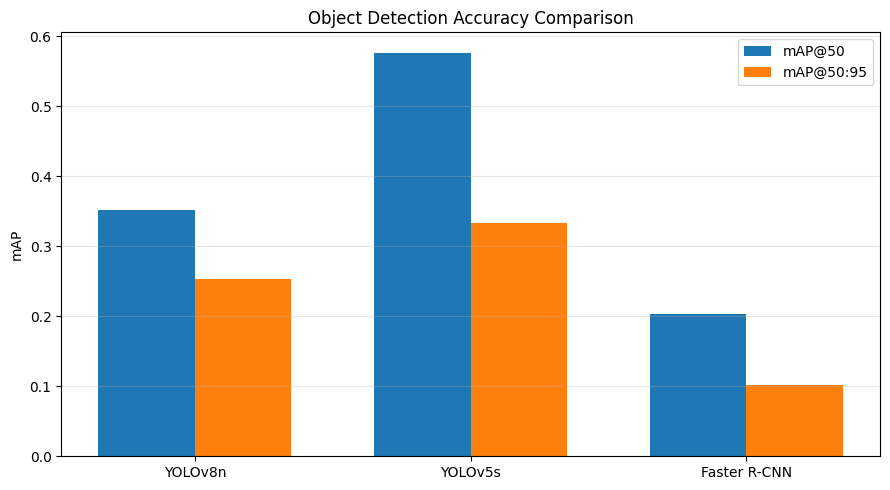

In [48]:
# ============================================================
# 30. PLOT mAP COMPARISON
# ============================================================

plt.figure(
    figsize=(9, 5)
)

x = np.arange(
    len(comparison)
)

width = 0.35


plt.bar(

    x - width / 2,

    comparison["mAP@50"],

    width,

    label="mAP@50"
)


plt.bar(

    x + width / 2,

    comparison["mAP@50:95"],

    width,

    label="mAP@50:95"
)


plt.xticks(
    x,
    comparison["Model"]
)

plt.ylabel(
    "mAP"
)

plt.title(
    "Object Detection Accuracy Comparison"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(

    f"{PROJECT_DIR}/plots/"
    "map_comparison.png",

    dpi=300,

    bbox_inches="tight"
)

plt.show()


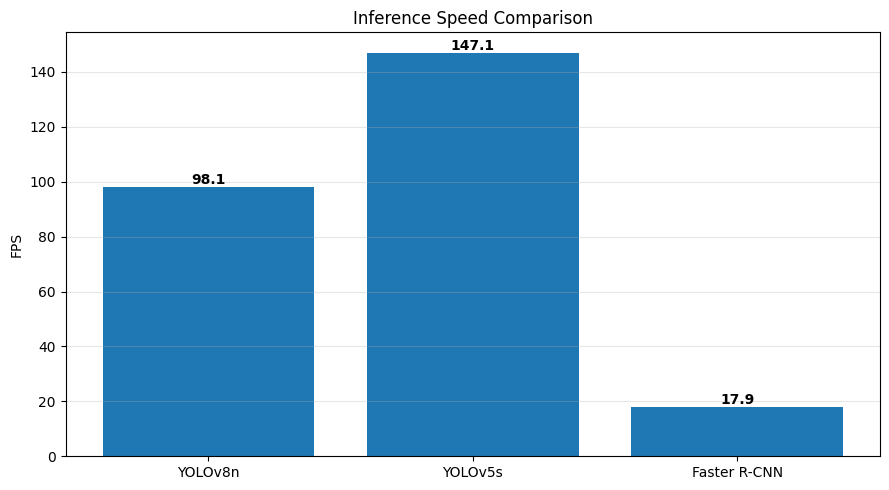

In [49]:
# ============================================================
# 31. PLOT INFERENCE SPEED
# ============================================================

plt.figure(
    figsize=(9, 5)
)


plt.bar(

    comparison["Model"],

    comparison["FPS"]
)


for i, value in enumerate(
    comparison["FPS"]
):

    plt.text(

        i,

        value,

        f"{value:.1f}",

        ha="center",

        va="bottom",

        fontweight="bold"
    )


plt.ylabel(
    "FPS"
)

plt.title(
    "Inference Speed Comparison"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(

    f"{PROJECT_DIR}/plots/"
    "fps_comparison.png",

    dpi=300,

    bbox_inches="tight"
)

plt.show()


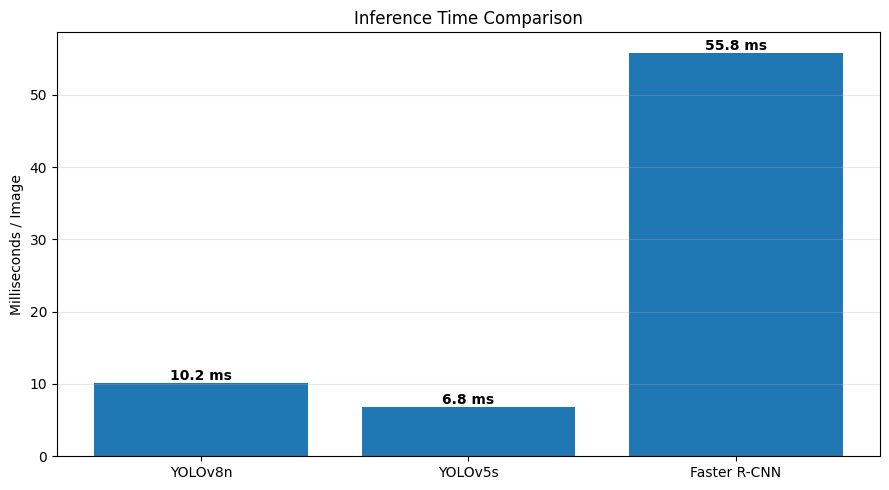

In [50]:
# ============================================================
# 32. PLOT INFERENCE TIME
# ============================================================

plt.figure(
    figsize=(9, 5)
)


plt.bar(

    comparison["Model"],

    comparison["Inference ms/image"]
)


for i, value in enumerate(
    comparison["Inference ms/image"]
):

    plt.text(

        i,

        value,

        f"{value:.1f} ms",

        ha="center",

        va="bottom",

        fontweight="bold"
    )


plt.ylabel(
    "Milliseconds / Image"
)

plt.title(
    "Inference Time Comparison"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(

    f"{PROJECT_DIR}/plots/"
    "inference_time_comparison.png",

    dpi=300,

    bbox_inches="tight"
)

plt.show()




SAMPLE YOLOv8 PREDICTIONS


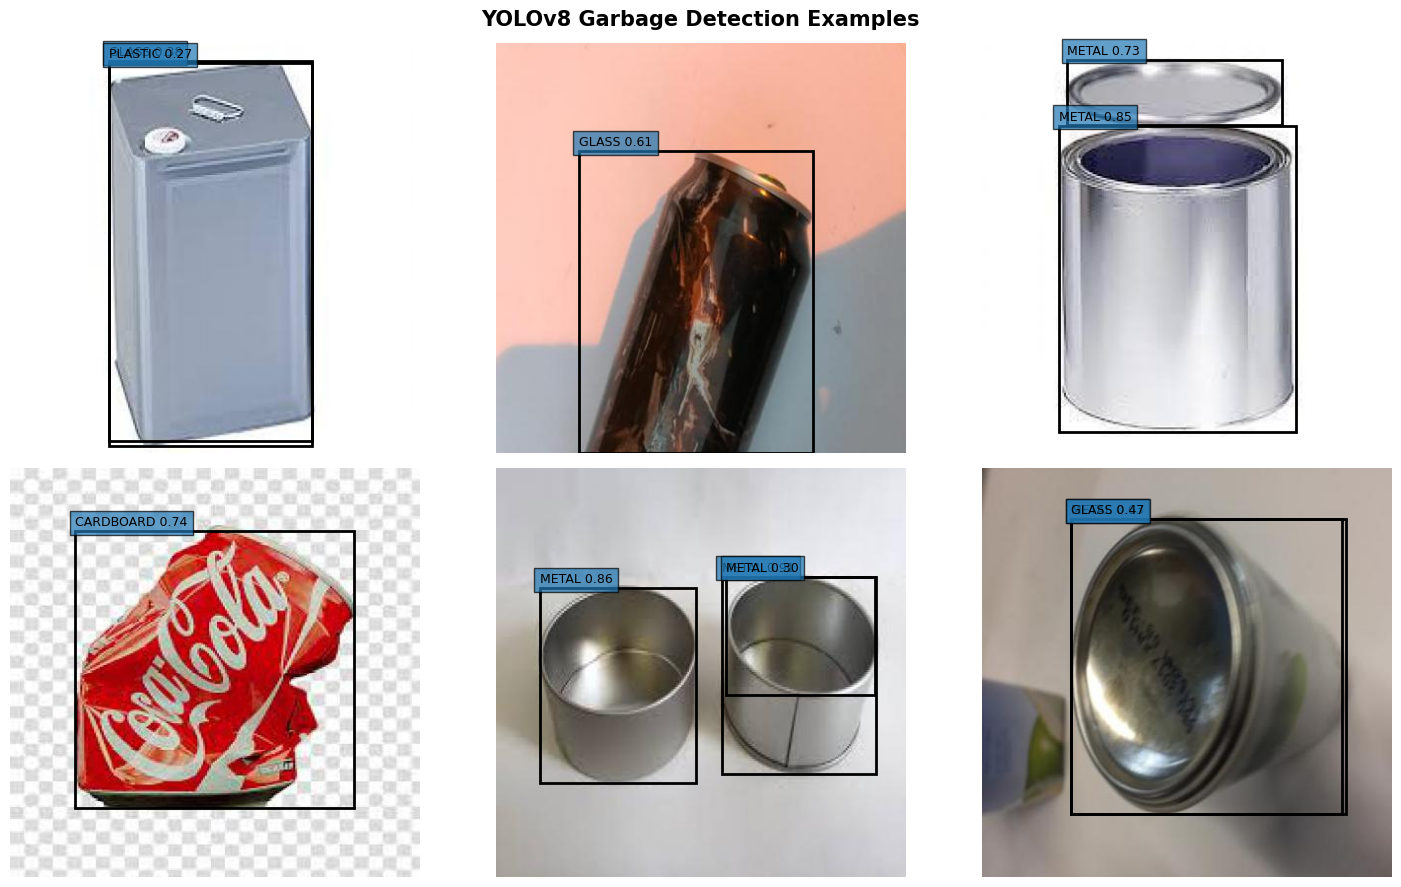

In [51]:
# ============================================================
# 33. VISUALIZE SAMPLE PREDICTIONS
# ============================================================

print("\n")
print("=" * 70)
print("SAMPLE YOLOv8 PREDICTIONS")
print("=" * 70)


sample_images = test_images[
    :min(
        6,
        len(test_images)
    )
]


results = yolov8_model.predict(

    source=sample_images,

    imgsz=IMG_SIZE,

    conf=0.25,

    device=0 if torch.cuda.is_available()
    else "cpu",

    verbose=False
)


fig, axes = plt.subplots(

    2,

    3,

    figsize=(15, 9)
)


axes = axes.flatten()


for ax, image_path, result in zip(

    axes,

    sample_images,

    results

):

    image = Image.open(
        image_path
    ).convert("RGB")


    ax.imshow(image)


    boxes = result.boxes


    if boxes is not None:

        for box in boxes:

            xyxy = (
                box.xyxy[0]
                .cpu()
                .numpy()
            )

            cls = int(
                box.cls[0]
                .cpu()
                .item()
            )

            conf = float(
                box.conf[0]
                .cpu()
                .item()
            )


            x1, y1, x2, y2 = xyxy


            rect = plt.Rectangle(

                (
                    x1,
                    y1
                ),

                x2 - x1,

                y2 - y1,

                fill=False,

                linewidth=2
            )


            ax.add_patch(
                rect
            )


            ax.text(

                x1,

                max(
                    0,
                    y1 - 5
                ),

                f"{CLASS_NAMES[cls]} "
                f"{conf:.2f}",

                fontsize=9,

                bbox=dict(
                    alpha=0.7
                )
            )


    ax.axis("off")


plt.suptitle(

    "YOLOv8 Garbage Detection Examples",

    fontsize=15,

    fontweight="bold"
)

plt.tight_layout()


plt.savefig(

    f"{PROJECT_DIR}/plots/"
    "sample_yolov8_predictions.png",

    dpi=300,

    bbox_inches="tight"
)

plt.show()

In [52]:

# ============================================================
# 34. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 100)
print("FINAL SUMMARY")
print("=" * 100)

print(
    comparison[
        [
            "Model",
            "Precision",
            "Recall",
            "mAP@50",
            "mAP@50:95",
            "Inference ms/image",
            "FPS"
        ]
    ].to_string(
        index=False
    )
)


print("\n" + "=" * 100)
print("FILES SAVED")
print("=" * 100)

print(
    f"All results: {PROJECT_DIR}/results/"
)

print(
    f"All plots  : {PROJECT_DIR}/plots/"
)

print(
    f"All models : {PROJECT_DIR}/models/"
)

print(
    "\nTraining and comparison completed."
)



FINAL SUMMARY
       Model  Precision   Recall   mAP@50  mAP@50:95  Inference ms/image        FPS
     YOLOv8n   0.440358 0.353557 0.351304   0.254004           10.196423  98.073608
     YOLOv5s   0.579000 0.505000 0.577000   0.333000            6.800000 147.058824
Faster R-CNN   0.223837 0.151319 0.203790   0.102253           55.842809  17.907409

FILES SAVED
All results: /content/Garbage_Detection_Comparison/results/
All plots  : /content/Garbage_Detection_Comparison/plots/
All models : /content/Garbage_Detection_Comparison/models/

Training and comparison completed.
